In [1]:
import sys
print(sys.executable)

/Users/anaisabecolinaarismendi/Documents/GitHub/CardioResearch/.venv/bin/python


In [5]:
import sys

# Esto fuerza la instalación de pandas y matplotlib usando el python exacto que lee el notebook
!{sys.executable} -m pip install pandas matplotlib

  Using cached pandas-3.0.5-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached numpy-2.5.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (123 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.5-cp314-cp314-macosx_11_0_arm64.whl (10.0 MB)
Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttool

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

print("¡Librerías importadas con éxito!")

¡Librerías importadas con éxito!


Top 5 revistas con más publicaciones:
journal
Journal of clinical medicine                         9
Medicina (Kaunas, Lithuania)                         5
Journal of cardiovascular development and disease    5
Journal of hypertension                              5
Medicine                                             4
Name: count, dtype: int64


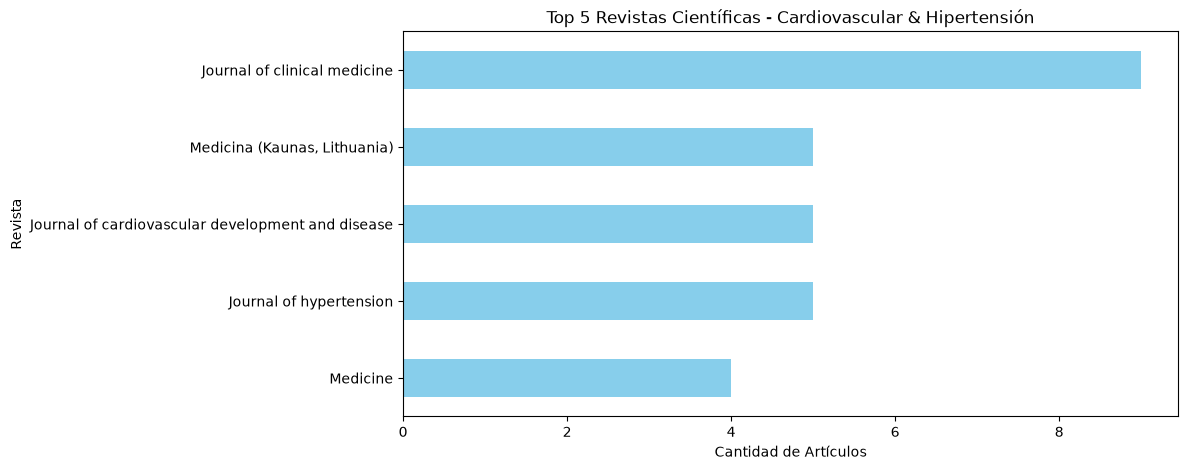

In [7]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# 1. Conectar a la base de datos y cargar los datos limpios
conn = sqlite3.connect("../cardioresearch.db")
df = pd.read_sql("SELECT * FROM clean_articles", conn)
# Si también quieres los datos originales con la revista:
df_original = pd.read_sql("SELECT pmid, journal FROM articles", conn)
conn.close()

# Unir para ver las revistas
df_completo = pd.merge(df, df_original, on="pmid")

# 2. Análisis rápido: Top 5 revistas más frecuentes
top_revistas = df_completo["journal"].value_counts().head(5)

print("Top 5 revistas con más publicaciones:")
print(top_revistas)

# 3. Graficar de forma sencilla
plt.figure(figsize=(10, 5))
top_revistas.plot(kind="barh", color="skyblue")
plt.title("Top 5 Revistas Científicas - Cardiovascular & Hipertensión")
plt.xlabel("Cantidad de Artículos")
plt.ylabel("Revista")
plt.gca().invert_yaxis()  # Para que la mayor aparezca arriba
plt.show()

Esta gráfica está mostrando el Top 5 de revistas donde más artículos de tu base de datos aparecen, dentro del conjunto de publicaciones relacionado con cardiovascular e hipertensión.

Qué significa cada eje:
- Eje Y: nombre de la revista
- Eje X: cantidad de artículos publicados en esa revista
- Cada barra representa cuántos registros de `df_completo` pertenecen a cada journal

En tu caso, los valores son:
- Journal of clinical medicine: 9
- Medicina (Kaunas, Lithuania): 5
- Journal of cardiovascular development and disease: 5
- Journal of hypertension: 5
- Medicine: 4

Entonces la gráfica dice:
- La revista con más artículos en este conjunto es “Journal of clinical medicine” con 9 publicaciones.
- Luego hay varios competidores con 5 cada uno.
- La diferencia entre revistas no es de proporciones, sino de conteos absolutos.

Qué está detrás:
- Se hace `df_completo["journal"].value_counts().head(5)`
- Eso cuenta cuántas veces aparece cada revista en el DataFrame unido por `pmid`
- Después se grafica en barras horizontales para que se vean mejor los nombres largos de las revistas

Importante:
- No muestra “calidad” ni “impacto” de la revista
- Solo muestra frecuencia de aparición en tu muestra
- Es una vista de distribución de publicaciones por revista, no de causalidad ni de relevancia clínica

La línea:
`plt.gca().invert_yaxis()` hace que la revista con más artículos quede arriba, como en una lista ordenada y más fácil de leer.

Si quieres, también te puedo explicar cómo interpretar la gráfica en relación con tu base de datos específica de artículos sobre hipertensión y cardiovascular.

In [8]:
from collections import Counter
import re
import pandas as pd
import sqlite3

# 1. Conectar a la base de datos y cargar los textos limpios
conn = sqlite3.connect("../cardioresearch.db")
df = pd.read_sql("SELECT combined_text FROM clean_articles", conn)
conn.close()

# 2. Lista básica de "stop words" (palabras vacías en inglés que no aportan valor analítico)
stop_words = {
    "the",
    "and",
    "of",
    "to",
    "in",
    "a",
    "for",
    "is",
    "on",
    "that",
    "by",
    "this",
    "with",
    "i",
    "you",
    "it",
    "not",
    "or",
    "be",
    "are",
    "from",
    "at",
    "as",
    "your",
    "all",
    "have",
    "new",
    "more",
    "an",
    "was",
    "we",
    "it",
    "patients",
    "study",
    "results",
    "associated",
}

# 3. Extraer y limpiar todas las palabras de los resúmenes
todas_las_palabras = []
for texto in df["combined_text"]:
    if isinstance(texto, str):
        # Separar por espacios
        palabras = texto.split()
        # Filtrar palabras cortas y stop words
        palabras_filtradas = [
            p for p in palabras if len(p) > 3 and p not in stop_words
        ]
        todas_las_palabras.extend(palabras_filtradas)

# 4. Contar frecuencias
contador = Counter(todas_las_palabras)
top_15_palabras = contador.most_common(15)

# 5. Mostrar resultados
print("--- Top 15 Palabras Más Frecuentes en los Estudios ---")
for palabra, frecuencia in top_15_palabras:
    print(f"{palabra}: {frecuencia} apariciones")

--- Top 15 Palabras Más Frecuentes en los Estudios ---
were: 424 apariciones
hypertension: 340 apariciones
cardiovascular: 306 apariciones
disease: 276 apariciones
risk: 268 apariciones
clinical: 180 apariciones
between: 142 apariciones
years: 140 apariciones
blood: 138 apariciones
among: 136 apariciones
pressure: 135 apariciones
using: 124 apariciones
mortality: 114 apariciones
these: 114 apariciones
higher: 110 apariciones


In [9]:
from collections import Counter
import pandas as pd
import sqlite3

# 1. Conectar a la base de datos y cargar los textos limpios
conn = sqlite3.connect("../cardioresearch.db")
df = pd.read_sql("SELECT combined_text FROM clean_articles", conn)
conn.close()

# 2. Diccionario ampliado de "stop words" (incluyendo auxiliares y términos genéricos de investigación)
stop_words = {
    "the",
    "and",
    "of",
    "to",
    "in",
    "a",
    "for",
    "is",
    "on",
    "that",
    "by",
    "this",
    "with",
    "i",
    "you",
    "it",
    "not",
    "or",
    "be",
    "are",
    "from",
    "at",
    "as",
    "your",
    "all",
    "have",
    "new",
    "more",
    "an",
    "was",
    "we",
    "its",
    "patients",
    "study",
    "results",
    "associated",
    "were",
    "between",
    "among",
    "using",
    "these",
    "they",
    "their",
    "which",
    "can",
    "has",
    "had",
    "been",
    "other",
    "also",
    "than",
    "two",
    "both",
    "data",
    "group",
    "groups",
    "who",
    "when",
    "after",
    "our",
}

# 3. Extraer y filtrar palabras
todas_las_palabras = []
for texto in df["combined_text"]:
    if isinstance(texto, str):
        palabras = texto.split()
        palabras_filtradas = [
            p for p in palabras if len(p) > 3 and p not in stop_words
        ]
        todas_las_palabras.extend(palabras_filtradas)

# 4. Contar y mostrar el nuevo Top 15 limpio
contador = Counter(todas_las_palabras)
top_15_limpio = contador.most_common(15)

print("--- Top 15 Términos Más Frecuentes (Corpus Limpio) ---")
for palabra, frecuencia in top_15_limpio:
    print(f"{palabra}: {frecuencia} apariciones")

--- Top 15 Términos Más Frecuentes (Corpus Limpio) ---
hypertension: 340 apariciones
cardiovascular: 306 apariciones
disease: 276 apariciones
risk: 268 apariciones
clinical: 180 apariciones
years: 140 apariciones
blood: 138 apariciones
pressure: 135 apariciones
mortality: 114 apariciones
higher: 110 apariciones
heart: 109 apariciones
outcomes: 107 apariciones
health: 107 apariciones
factors: 103 apariciones
analysis: 98 apariciones
